In [443]:
# - Pandas
# - Numpy
# - Matplotlib
# - Seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.decomposition import PCA

from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import FunctionTransformer

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

from sklearn.metrics import classification_report
from sklearn.neighbors import KNeighborsClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.neural_network import MLPClassifier


### 1. Data load and Initial EDA

To start I will load the data and extract the target columns and split the data into training and test datasets.

I will then do some intial EDA to help understand the dataset that we are dealing with.

In [444]:
# First lets load the data into a dataframe
df = pd.read_csv('./insurance.csv')

# Create a new column 'insurance_cost_binary'
# 0 if insurance_cost is less than or equal to the median insurance cost
# 1 otherwise
median_insurance_cost = df['insurance_cost'].median()
df['insurance_cost_binary'] = (df['insurance_cost'] > median_insurance_cost).astype(int)

# remove the original insurance_cost column
df.drop(columns=['insurance_cost'], inplace=True)

# split the data into features and target
X = df.drop(columns=['insurance_cost_binary'])
y = df[['insurance_cost_binary']]

# split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

# use the concat function to combine the training data and the target data as its useful for plotting
X_y_train = pd.concat([X_train, y_train], axis=1)

X_train.head()


,age,gender,bmi,children,smoker,region
332,26,male,33.915,1,no,northwest
355,27,male,32.585,3,no,northeast
138,20,male,28.025,1,yes,northwest
381,28,female,25.800,0,no,southwest
292,25,female,32.230,1,no,southeast


In [445]:
y_train.head()

,insurance_cost_binary
332,0
355,0
138,1
381,0
292,1


In [446]:
# print the data types of the columns
print("Data types of the columns:") 
print(X_train.dtypes)


# Display dataset shape
print('\nDataset shape:', X_train.shape)

Data types of the columns:
age           int64
gender          str
bmi         float64
children      int64
smoker          str
region          str
dtype: object

Dataset shape: (936, 6)


### Missing Values

In [447]:
# Lets see if there are any missing values
X_train.isna().sum()

age         0
gender      0
bmi         0
children    0
smoker      0
region      0
dtype: int64

### Categorical Attributes

In [448]:
# Frequency counts for categorical attributes
categorical_attributes  = X_train.select_dtypes(include=['str']).columns

print("\nCategorical attributes:\n")
print(list(categorical_attributes))

print("\nFrequency counts for categorical attributes:\n")

for column in categorical_attributes: 
    print("\n")
    print(df[column].value_counts(dropna=False))
    print("--------------------------------")


Categorical attributes:

['gender', 'smoker', 'region']

Frequency counts for categorical attributes:



gender
male      676
female    662
Name: count, dtype: int64
--------------------------------


smoker
no     1064
yes     274
Name: count, dtype: int64
--------------------------------


region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64
--------------------------------


### Numerical Attributes

In [449]:
# Lets look at the summary statistics for numerical attributes

print("\nSummary statistics for numeric attributes:\n")

X_train.describe()


Summary statistics for numeric attributes:



,age,bmi,children
count,936.000000,936.000000,936.000000
mean,39.099359,30.661608,1.064103
std,14.083242,6.142317,1.186445
min,18.000000,16.815000,0.000000
25%,26.000000,26.220000,0.000000
50%,39.500000,30.400000,1.000000
75%,51.000000,34.770000,2.000000
max,64.000000,53.130000,5.000000


               age       bmi  children
age       1.000000  0.109462  0.061451
bmi       0.109462  1.000000 -0.003998
children  0.061451 -0.003998  1.000000


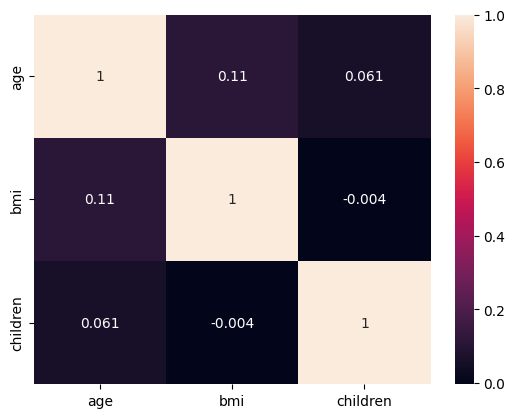

In [450]:
# correlation matrix
corr_matrix = X_train.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True)
print(corr_matrix)

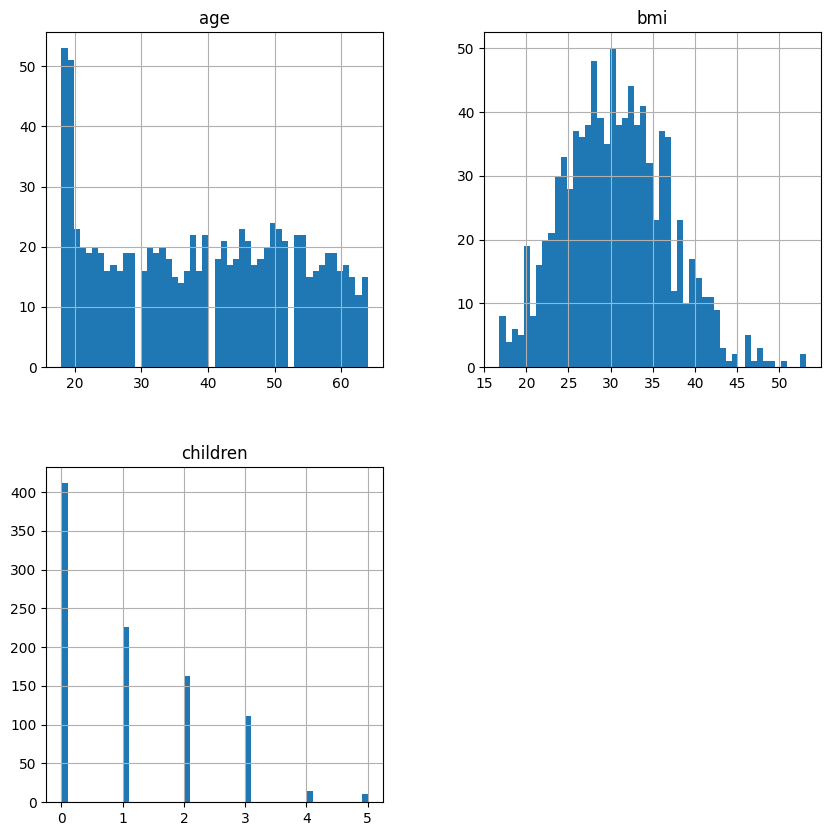

In [451]:
X_train.hist(bins=50, figsize=(10, 10))
plt.show()

<Axes: >

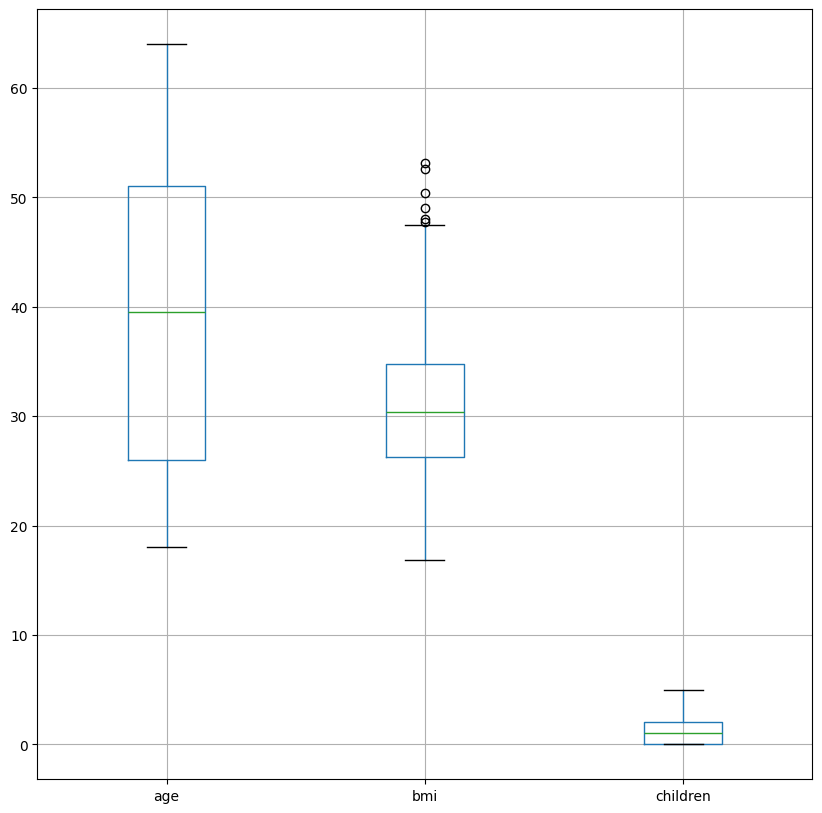

In [452]:
X_train.boxplot(figsize=(10, 10))

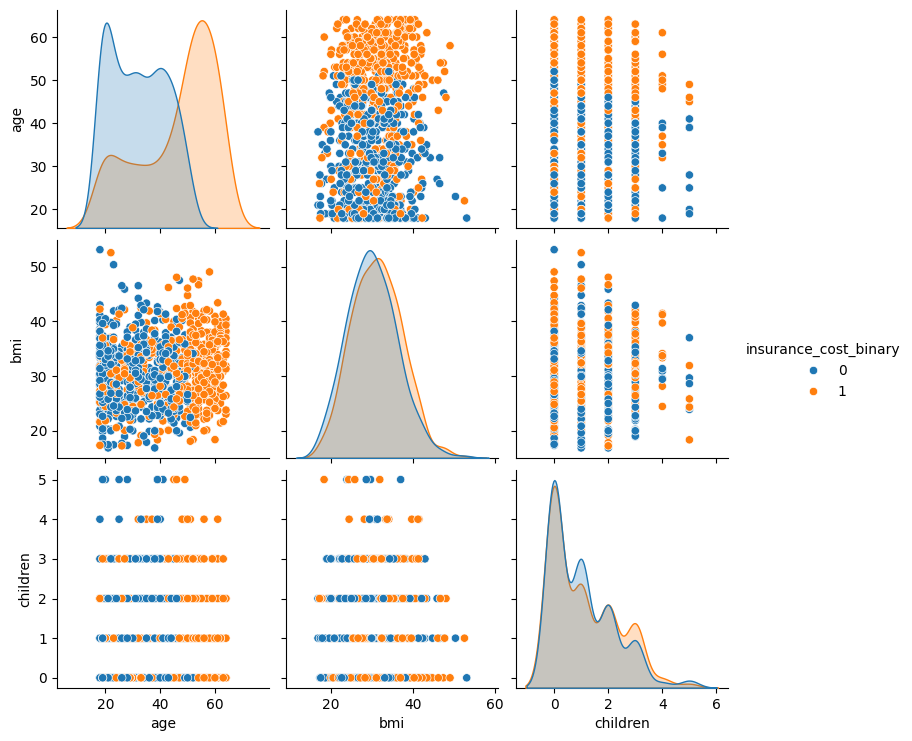

In [453]:
sns.pairplot(X_y_train, hue='insurance_cost_binary')
plt.show()

### Summary of Inital EDA

The dataset looks quite clean with only a small amount of columns and no missing data.

Observations:
1. bmi is the only column that has any real outliers as seen from the box plots.
2. There is some moderate correlation between age and insurance_cost_binary
3. There is a slight positive correlation between bmi and insurance_cost_binary
4. There are 3 categorical attributes: 'gender', 'smoker' and 'region'
5. age looks uniformly distributed aprt from ages under < 20
6. bmi looks like its normally distributed.
7. children appears to be right skewed.




### 2. Create Pipelines

Here I will firsty create a few  basic preprocessing Pipelines to look at a PCA with a SVM model to get a feel for it.
I will then try to gneralize to multiple models, dim reduction methods and hyperparams. 

In [454]:
# Log transform for skewed data
def log_transform(x):
    return np.log(x+1)

# Create a pipeline for the categorical attributes
categorical_pipeline = Pipeline(
    [
        ('one_hot_encoder', OneHotEncoder())
    ]
)

numerical_attributes = df.select_dtypes(include=['float64', 'int64']).columns

print("numerical_attributes = ", numerical_attributes)
print("categorical_attributes = ", categorical_attributes)

log_pipeline = Pipeline(
    [
        ('log_transformer', FunctionTransformer(log_transform, feature_names_out='one-to-one'))
    ]
)

bmi_pipeline = Pipeline(
    [
        ('standard_scaler', StandardScaler())
    ]
)

age_pipeline = Pipeline(
    [
        ('passthrough', 'passthrough')
    ]
)

insurance_cost_binary_pipeline = Pipeline(
    [
        ('passthrough', 'passthrough')
    ]
)   


# Combine the pipelines
column_transformer = ColumnTransformer(
    [
        ('categorical_pipeline', categorical_pipeline, categorical_attributes),
        ('age_pipeline', age_pipeline, ['age']),
        ('bmi_pipeline', bmi_pipeline, ['bmi']),
        ('children_pipeline', log_pipeline, ['children'])
    ]
    
)
preprocessing_pipeline = Pipeline(
    [
        ('column_transformer', column_transformer)
    ]
)


numerical_attributes =  Index(['age', 'bmi', 'children', 'insurance_cost_binary'], dtype='str')
categorical_attributes =  Index(['gender', 'smoker', 'region'], dtype='str')


### Run the Pipeline on training data

['categorical_pipeline__gender_female' 'categorical_pipeline__gender_male'
 'categorical_pipeline__smoker_no' 'categorical_pipeline__smoker_yes'
 'categorical_pipeline__region_northeast'
 'categorical_pipeline__region_northwest'
 'categorical_pipeline__region_southeast'
 'categorical_pipeline__region_southwest' 'age_pipeline__age'
 'bmi_pipeline__bmi' 'children_pipeline__children']


array([[<Axes: title={'center': 'categorical_pipeline__gender_female'}>,
        <Axes: title={'center': 'categorical_pipeline__gender_male'}>,
        <Axes: title={'center': 'categorical_pipeline__smoker_no'}>],
       [<Axes: title={'center': 'categorical_pipeline__smoker_yes'}>,
        <Axes: title={'center': 'categorical_pipeline__region_northeast'}>,
        <Axes: title={'center': 'categorical_pipeline__region_northwest'}>],
       [<Axes: title={'center': 'categorical_pipeline__region_southeast'}>,
        <Axes: title={'center': 'categorical_pipeline__region_southwest'}>,
        <Axes: title={'center': 'age_pipeline__age'}>],
       [<Axes: title={'center': 'bmi_pipeline__bmi'}>,
        <Axes: title={'center': 'children_pipeline__children'}>,
        <Axes: >]], dtype=object)

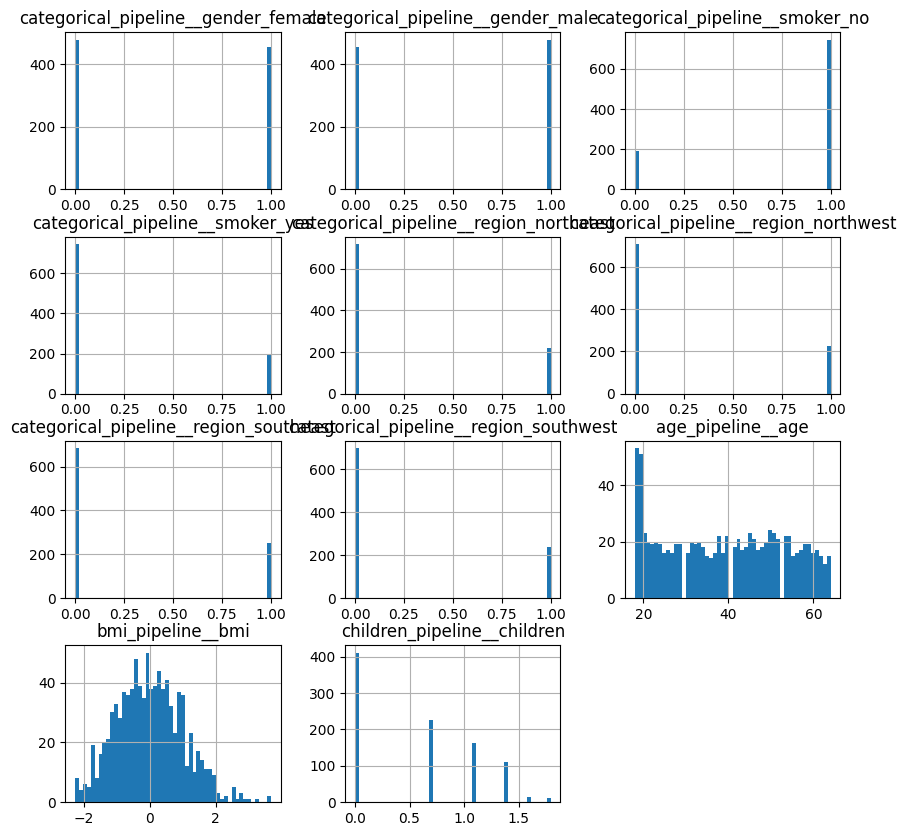

In [455]:
prepared = preprocessing_pipeline.fit_transform(X_train)

print(preprocessing_pipeline.get_feature_names_out())

X_train_prepared = pd.DataFrame(prepared, columns=preprocessing_pipeline.get_feature_names_out(), index=X_train.index)

X_train_prepared.hist(bins=50, figsize=(10, 10))

### 3 Features PCA

Explained variance: [0.98573736 0.00507709 0.00251456]
Cumulative: [0.98573736 0.99081445 0.99332902]


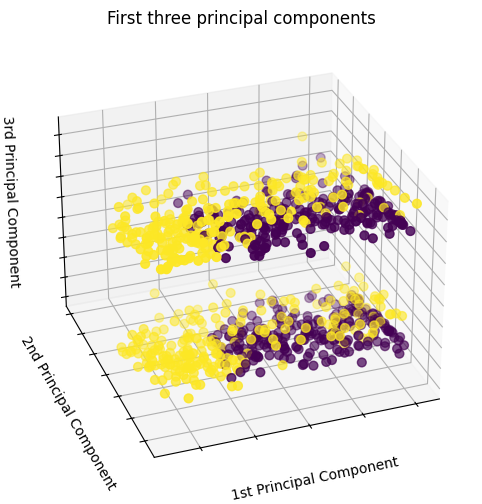

In [456]:
# run PCA on the prepared training data

pca = PCA(n_components=3)
X_reduced = pca.fit_transform(X_train_prepared)

print("Explained variance:", pca.explained_variance_ratio_)
print("Cumulative:", np.cumsum(pca.explained_variance_ratio_))

fig = plt.figure(1, figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d", elev=-150, azim=110)

scatter = ax.scatter(
    X_reduced[:, 0],
    X_reduced[:, 1],
    X_reduced[:, 2],
    c=y_train['insurance_cost_binary'],
    s=40,
)

ax.set(
    title="First three principal components",
    xlabel="1st Principal Component",
    ylabel="2nd Principal Component",
    zlabel="3rd Principal Component",
)
ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])

plt.show()

### 2 Features PCA

[[-13.09371152   0.58690225]
 [-12.09297067   0.35678492]]
Explained variance: [0.98573736 0.00507709]
Cumulative: [0.98573736 0.99081445]


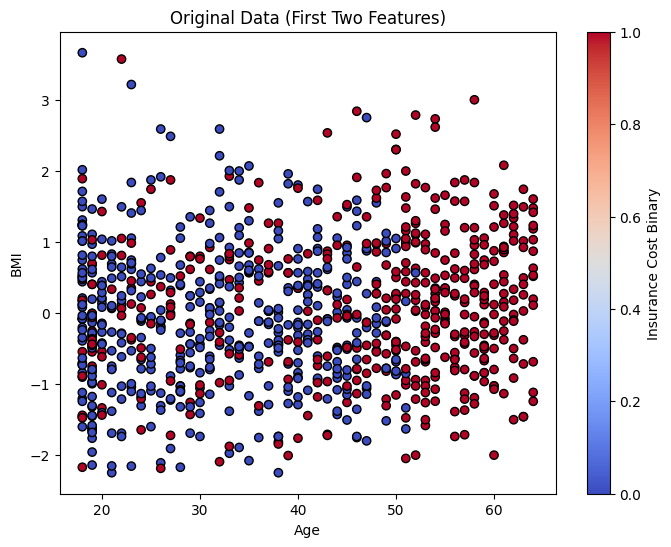

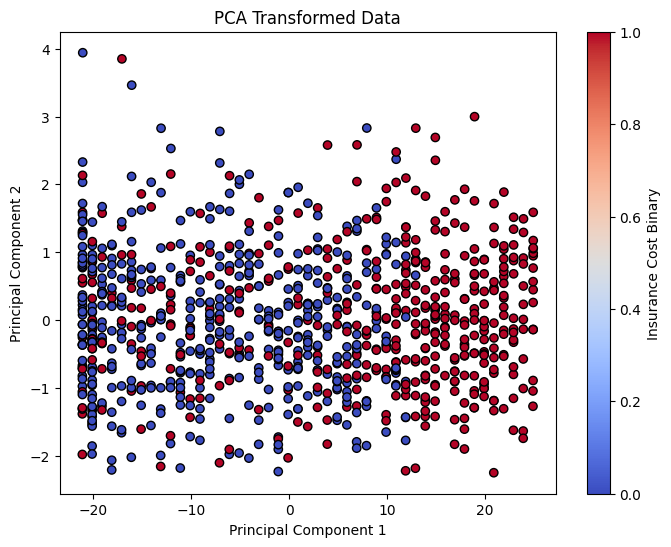

In [457]:
# run PCA on the prepared training data

pca = PCA(n_components=2)

X_reduced = pca.fit_transform(X_train_prepared)
print(X_reduced[:2])


print("Explained variance:", pca.explained_variance_ratio_)
print("Cumulative:", np.cumsum(pca.explained_variance_ratio_))


plt.figure(figsize=(8,6))
plt.scatter(X_train_prepared['age_pipeline__age'], X_train_prepared['bmi_pipeline__bmi'], c=y_train['insurance_cost_binary'], cmap='coolwarm', edgecolor='k')
plt.xlabel("Age")
plt.ylabel("BMI")
plt.title("Original Data (First Two Features)")
plt.colorbar(label="Insurance Cost Binary")
plt.show()

plt.figure(figsize=(8,6))
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y_train['insurance_cost_binary'], cmap='coolwarm', edgecolor='k')
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Transformed Data")
plt.colorbar(label="Insurance Cost Binary")
plt.show()


### Pipeline With 2 Feature PCA

['pca0' 'pca1']


,pca0,pca1
332,-13.093712,0.586902
355,-12.092971,0.356785
138,-19.103319,-0.277833
381,-11.105578,-0.777974
292,-14.097556,0.453852
1090,14.900951,0.187870
1075,14.913856,1.458989
141,-19.086157,1.056425
676,0.905046,0.977810
626,-1.091098,0.663952


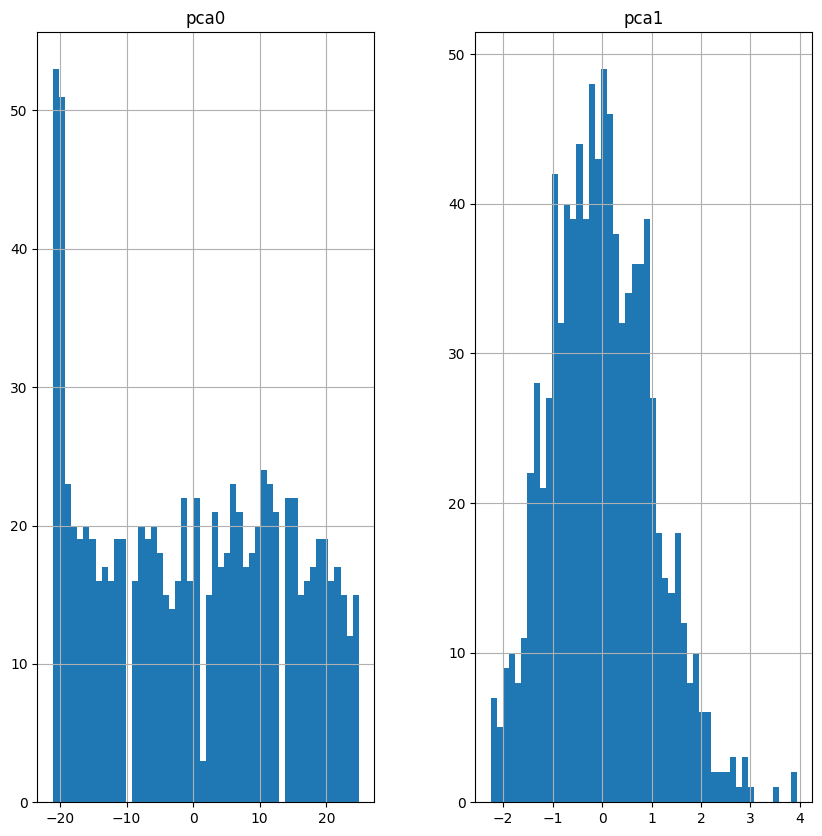

In [458]:
pca_pipeline = Pipeline(
    [
        # reuse the column transformer from the previous pipeline
        ('column_transformer', column_transformer),
        ('pca', PCA(n_components=2)),
    ]
)

prepared = pca_pipeline.fit_transform(X_train)

print(pca_pipeline.get_feature_names_out())

X_train_prepared = pd.DataFrame(prepared, columns=pca_pipeline.get_feature_names_out(), index=X_train.index)

X_train_prepared.hist(bins=50, figsize=(10, 10), )

X_train_prepared.head(20)

### Pipeline with SVM

In [459]:
svm_pipeline = Pipeline(
    [
        # reuse the column transformer from the previous pipeline
        ('column_transformer', column_transformer),
        ('pca', PCA(n_components=2)),
         ("svm",SVC(C=10,kernel='rbf')),
    ]
)

prepared = svm_pipeline.fit(X_train, y_train)



# score of testing data
print("Score is:",svm_pipeline.score(X_test, y_test))
 
# precision recall f1-score support report
y_pred = svm_pipeline.predict(X_test)
report = classification_report(y_test, y_pred)
print("Classificaion Report")
print(report)


Score is: 0.7736318407960199
Classificaion Report
              precision    recall  f1-score   support

           0       0.70      0.96      0.81       203
           1       0.93      0.59      0.72       199

    accuracy                           0.77       402
   macro avg       0.82      0.77      0.77       402
weighted avg       0.81      0.77      0.77       402



/home/kris/school/da/data/e-tivity3/myenv/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


### KNN Pipeline

In [460]:
knn_pipeline = Pipeline(
    [
        # reuse the column transformer from the previous pipeline
        ('column_transformer', column_transformer),
        ('pca', PCA(n_components=2)),
         ("knn",KNeighborsClassifier(n_neighbors=500)),
    ]
)

prepared =  knn_pipeline.fit(X_train, y_train)



# score of testing data
print("Score is:",knn_pipeline.score(X_test, y_test))
 
# precision recall f1-score support report
y_pred = knn_pipeline.predict(X_test)   
report = classification_report(y_test, y_pred)
print("Classificaion Report")
print(report)

Score is: 0.763681592039801
Classificaion Report
              precision    recall  f1-score   support

           0       0.73      0.85      0.78       203
           1       0.81      0.68      0.74       199

    accuracy                           0.76       402
   macro avg       0.77      0.76      0.76       402
weighted avg       0.77      0.76      0.76       402



/home/kris/school/da/data/e-tivity3/myenv/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


### Random Forest Pipeline




In [461]:
rf_pipeline = Pipeline(
    [
        # reuse the column transformer from the previous pipeline
        ('column_transformer', column_transformer),
        ('pca', PCA(n_components=2)),
         ("rf",RandomForestClassifier(n_estimators=100, random_state=42)),
    ]
)

prepared =  rf_pipeline.fit(X_train, y_train)


# score of testing data
print("Score is:",rf_pipeline.score(X_test, y_test))
 
# precision recall f1-score support report
y_pred = rf_pipeline.predict(X_test)   
report = classification_report(y_test, y_pred)
print("Classificaion Report")
print(report)


/home/kris/school/da/data/e-tivity3/myenv/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Score is: 0.7711442786069652
Classificaion Report
              precision    recall  f1-score   support

           0       0.73      0.86      0.79       203
           1       0.82      0.68      0.75       199

    accuracy                           0.77       402
   macro avg       0.78      0.77      0.77       402
weighted avg       0.78      0.77      0.77       402



### MLP Pipeline

In [464]:
mlp_pipeline = Pipeline(
    [
        # reuse the column transformer from the previous pipeline
        ('column_transformer', column_transformer),
        ('pca', PCA(n_components=2)),
         ("mlp",MLPClassifier(hidden_layer_sizes=(100,100), max_iter=1000, random_state=42)),
    ]
)

prepared =  mlp_pipeline.fit(X_train, y_train)


# score of testing data
print("Score is:",mlp_pipeline.score(X_test, y_test))
 
# precision recall f1-score support report
y_pred = mlp_pipeline.predict(X_test)   
report = classification_report(y_test, y_pred)
print("Classificaion Report")
print(report)

/home/kris/school/da/data/e-tivity3/myenv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1223: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Score is: 0.7860696517412935
Classificaion Report
              precision    recall  f1-score   support

           0       0.73      0.93      0.81       203
           1       0.90      0.64      0.75       199

    accuracy                           0.79       402
   macro avg       0.81      0.78      0.78       402
weighted avg       0.81      0.79      0.78       402



### Summary after running some initial models

I have tested SVM, Random Forest as well as MLP and KNN models all ran after a 2 component PCA and and I am seeing model scores in the ~~70% range..

Now I attempt to generalize gthis and run a search for the optima model and set of params.